### Importing the Modules

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report, recall_score, f1_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

### Reading and Analyzing of the Datasets

In [14]:
heart_dataset = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")
df = heart_dataset.copy()
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [15]:
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
age,1190.00,53.72,9.36,28.00,47.00,54.00,60.00,77.00
sex,1190.00,0.76,0.42,0.00,1.00,1.00,1.00,1.00
chest pain type,1190.00,3.23,0.94,1.00,3.00,4.00,4.00,4.00
resting bp s,1190.00,132.15,18.37,0.00,120.00,130.00,140.00,200.00
cholesterol,1190.00,210.36,101.42,0.00,188.00,229.00,269.75,603.00
fasting blood sugar,1190.00,0.21,0.41,0.00,0.00,0.00,0.00,1.00
resting ecg,1190.00,0.70,0.87,0.00,0.00,0.00,2.00,2.00
max heart rate,1190.00,139.73,25.52,60.00,121.00,140.50,160.00,202.00
exercise angina,1190.00,0.39,0.49,0.00,0.00,0.00,1.00,1.00
oldpeak,1190.00,0.92,1.09,-2.60,0.00,0.60,1.60,6.20


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [17]:
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [18]:
for i in list(df.columns):
    print("{} -- {}".format(i, df[i].value_counts().shape[0]))

age -- 50
sex -- 2
chest pain type -- 4
resting bp s -- 67
cholesterol -- 222
fasting blood sugar -- 2
resting ecg -- 3
max heart rate -- 119
exercise angina -- 2
oldpeak -- 53
ST slope -- 4
target -- 2


### Dropping Duplicates

In [19]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 918 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  918 non-null    int64  
 1   sex                  918 non-null    int64  
 2   chest pain type      918 non-null    int64  
 3   resting bp s         918 non-null    int64  
 4   cholesterol          918 non-null    int64  
 5   fasting blood sugar  918 non-null    int64  
 6   resting ecg          918 non-null    int64  
 7   max heart rate       918 non-null    int64  
 8   exercise angina      918 non-null    int64  
 9   oldpeak              918 non-null    float64
 10  ST slope             918 non-null    int64  
 11  target               918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 93.2 KB


### Outlier Detection

In [20]:
numeric_list = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
df_numeric = df.loc[:, numeric_list]
df_numeric.head()

,age,resting bp s,cholesterol,max heart rate,oldpeak
0,40,140,289,172,0.0
1,49,160,180,156,1.0
2,37,130,283,98,0.0
3,48,138,214,108,1.5
4,54,150,195,122,0.0


In [21]:
df_numeric.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
age,918.00,53.51,9.43,28.00,47.00,54.00,60.00,77.00
resting bp s,918.00,132.40,18.51,0.00,120.00,130.00,140.00,200.00
cholesterol,918.00,198.80,109.38,0.00,173.25,223.00,267.00,603.00
max heart rate,918.00,136.81,25.46,60.00,120.00,138.00,156.00,202.00
oldpeak,918.00,0.89,1.07,-2.60,0.00,0.60,1.50,6.20


In [22]:
# outlier detection
for i in numeric_list:
    
    # IQR
    Q1 = np.percentile(df.loc[:, i],25)
    Q3 = np.percentile(df.loc[:, i],75)
    
    IQR = Q3 - Q1
    
    print("Old shape: ", df.loc[:, i].shape)
    
    # upper bound
    upper = np.where(df.loc[:, i] >= (Q3 + 1.5 * IQR))
    
    # lower bound
    lower = np.where(df.loc[:, i] <= (Q1 - 1.5 * IQR))
    
    print("{} -- {}".format(upper, lower))
    
    try:
        df.drop(upper[0], inplace = True)
    except: print("KeyError: {} not found in axis".format(upper[0]))
    
    try:
        df.drop(lower[0], inplace = True)
    except:  print("KeyError: {} not found in axis".format(lower[0]))
        
    print("New shape: ", df.shape)

Old shape:  (918,)
(array([], dtype=int64),) -- (array([], dtype=int64),)
New shape:  (918, 12)
Old shape:  (918,)
(array([ 86, 109, 123, 132, 189, 190, 191, 215, 241, 274, 275, 277, 278,
       365, 372, 397, 399, 411, 423, 432, 475, 479, 491, 543, 550, 585,
       592, 648, 673, 702, 725, 732, 759, 774, 780, 825, 855, 880, 890,
       901]),) -- (array([314, 449]),)
KeyError: [ 86 109 123 132 189 190 191 215 241 274 275 277 278 365 372 397 399 411
 423 432 475 479 491 543 550 585 592 648 673 702 725 732 759 774 780 825
 855 880 890 901] not found in axis
New shape:  (916, 12)
Old shape:  (916,)
(array([ 28,  30,  69,  76, 103, 149, 250, 494, 614, 622, 665, 794]),) -- (array([293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305,
       306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318,
       319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331,
       332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344,
       345, 346, 347, 348, 349, 3

### Categorical Feature Analysis

In [23]:
df.columns

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='str')

In [24]:
categorical_list = ["sex", "chest pain type", "fasting blood sugar", "resting ecg", "exercise angina", 
                    "ST slope", "target"]

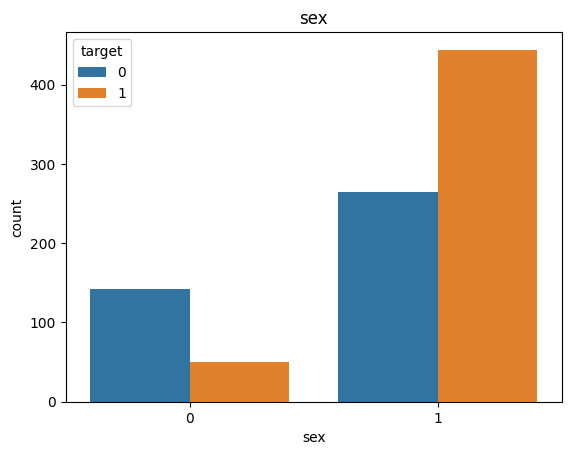

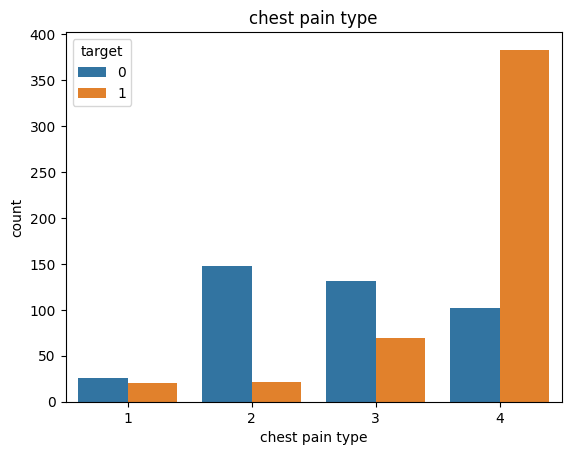

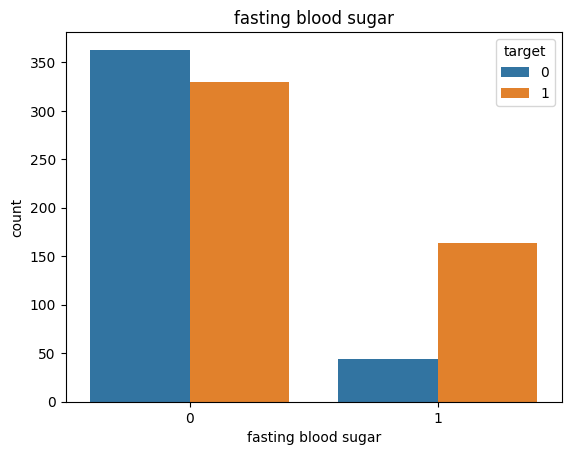

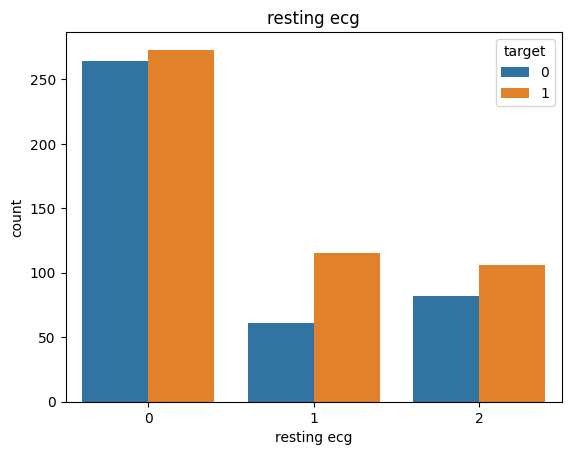

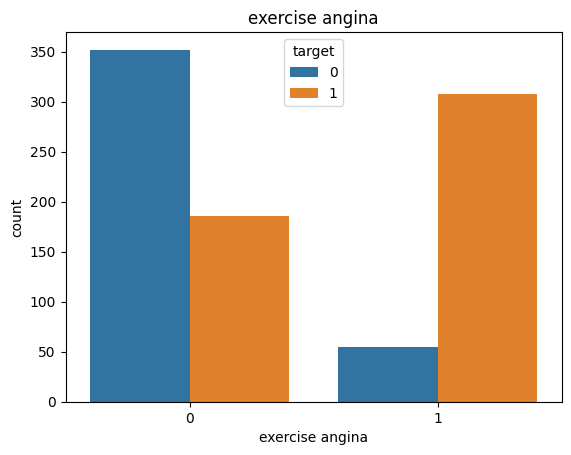

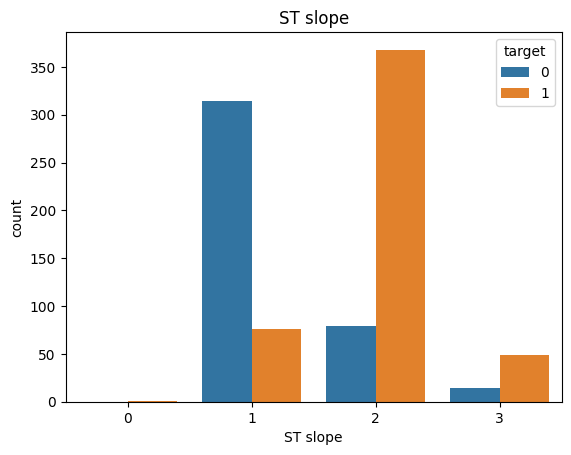

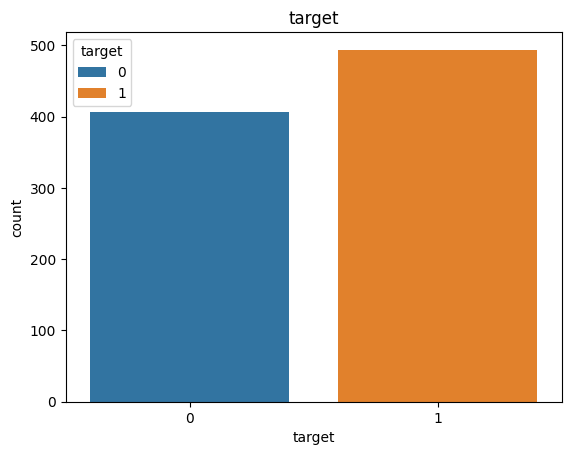

In [25]:
df_categoric = df.loc[:, categorical_list]
for i in categorical_list:
    plt.figure()
    sns.countplot(x = i, data = df_categoric, hue = "target")
    plt.title(i)

In [26]:
results = []
for var in categorical_list:
    contingency_table = pd.crosstab(df[var], df["target"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    results.append({"Variable": var, "Chi2": chi2, "p-value": p})
chi_results = pd.DataFrame(results)
chi_results

,Variable,Chi2,p-value
0,sex,80.165274,3.443664e-19
1,chest pain type,270.316719,2.635995e-58
2,fasting blood sugar,61.734291,3.930749e-15
3,resting ecg,11.489307,3.199844e-03
4,exercise angina,219.189230,1.359048e-49
5,ST slope,347.371471,5.531278e-75
6,target,896.966878,4.479054e-197


In [27]:
for var in categorical_list:
    print(f"\n--- {var} ---")
    ct_counts = pd.crosstab(df[var], df["target"])
    ct_percent = pd.crosstab(df[var], df["target"], normalize="index") * 100
    
    print("Counts:")
    print(ct_counts)
    print("\nPercentages:")
    print(ct_percent.round(1))


--- sex ---
Counts:
target    0    1
sex             
0       142   50
1       265  444

Percentages:
target     0     1
sex               
0       74.0  26.0
1       37.4  62.6

--- chest pain type ---
Counts:
target             0    1
chest pain type          
1                 26   20
2                148   22
3                131   69
4                102  383

Percentages:
target              0     1
chest pain type            
1                56.5  43.5
2                87.1  12.9
3                65.5  34.5
4                21.0  79.0

--- fasting blood sugar ---
Counts:
target                 0    1
fasting blood sugar          
0                    363  330
1                     44  164

Percentages:
target                  0     1
fasting blood sugar            
0                    52.4  47.6
1                    21.2  78.8

--- resting ecg ---
Counts:
target         0    1
resting ecg          
0            264  273
1             61  115
2             82  106

Percentages

### Numeric Feature Analysis

In [31]:
numeric_list = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak", "target"]

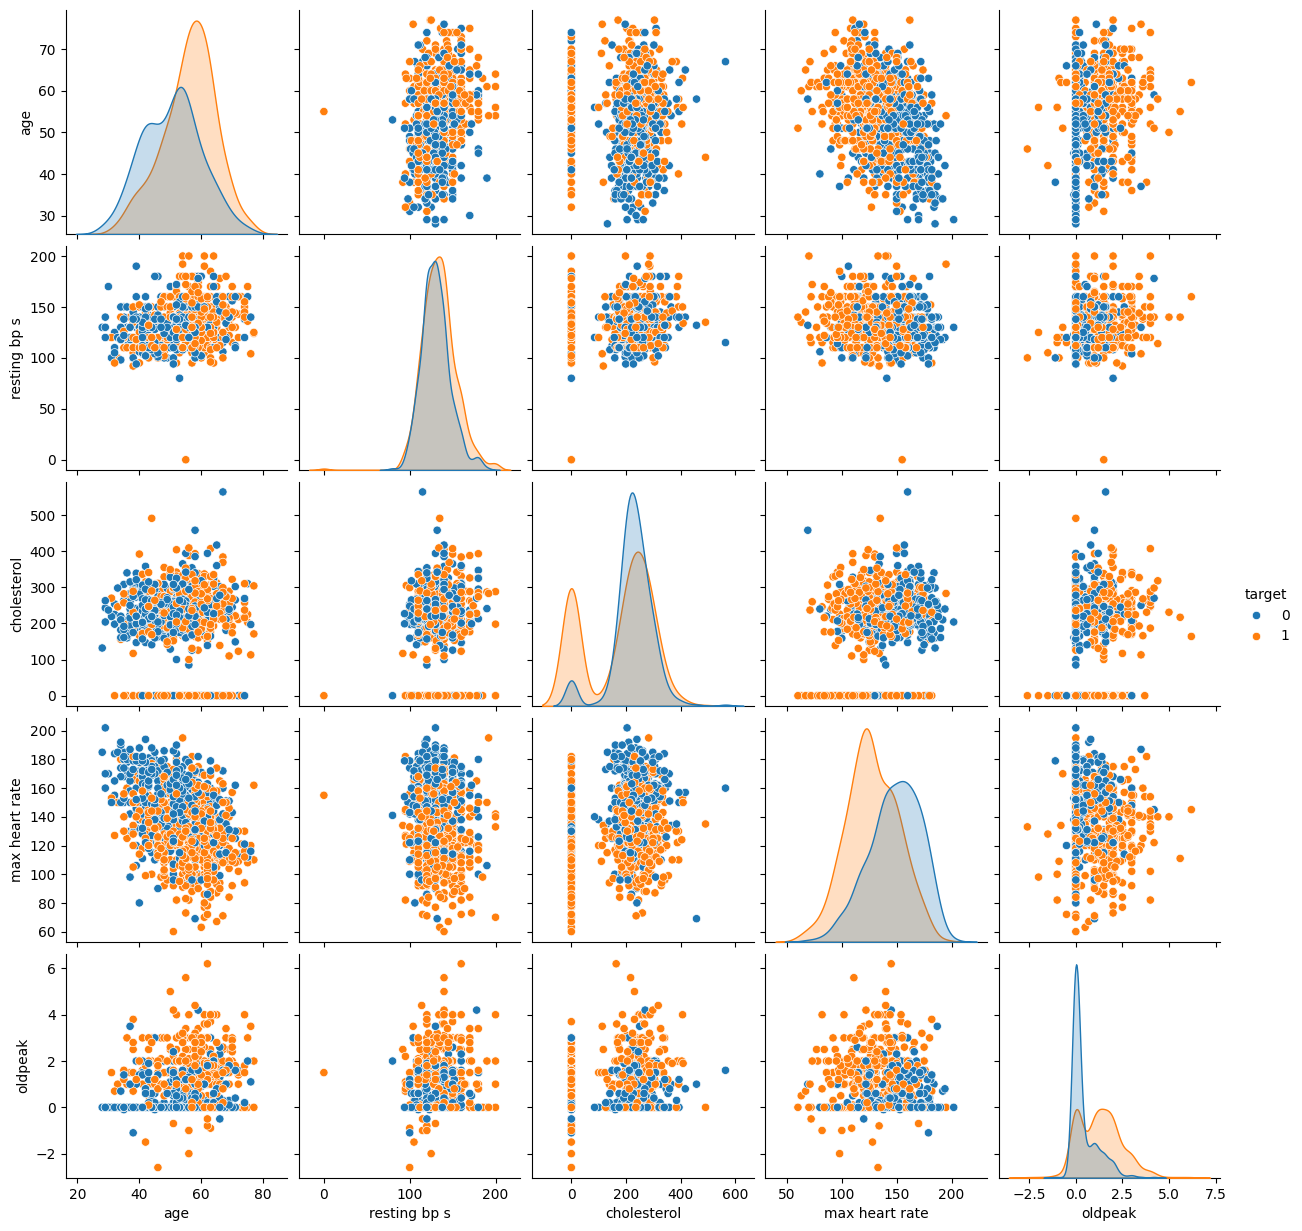

In [32]:
df_numeric = df.loc[:, numeric_list]
sns.pairplot(data = df_numeric, hue = "target", diag_kind = "kde")

### Boxplot Analysis

In [33]:
df_scaled = df[numeric_list].apply(lambda x: (x - x.min()) / (x.max() - x.min()) * 100)
df_scaled["target"] = df["target"]

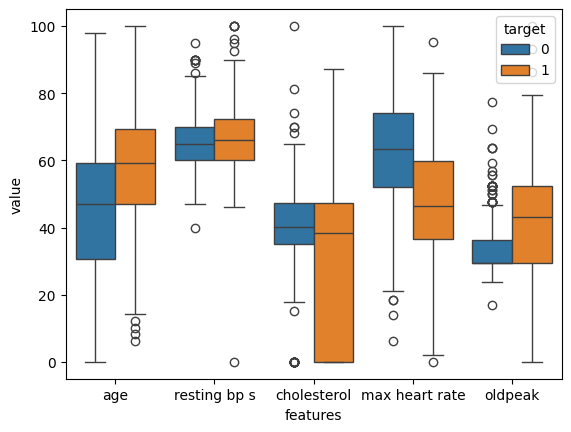

In [34]:
df_melted = df_scaled.melt(id_vars= "target", var_name= "features", value_name= "value")
sns.boxplot(x = "features", y= "value", hue= "target", data= df_melted)
plt.show()

### Swarmplot Analysis

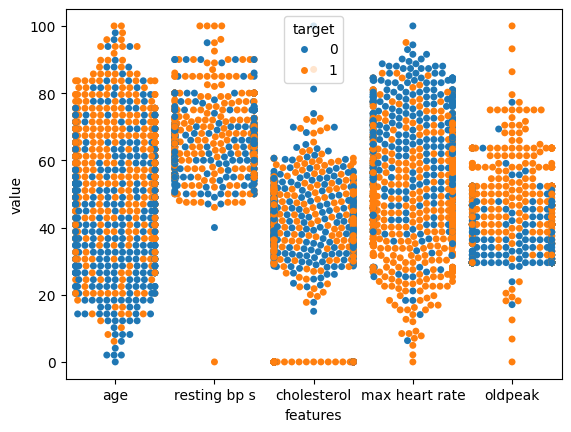

In [35]:
plt.figure()
sns.swarmplot(x = "features", y = "value", hue = "target", data = df_melted)
plt.show();

### Catplot Analysis

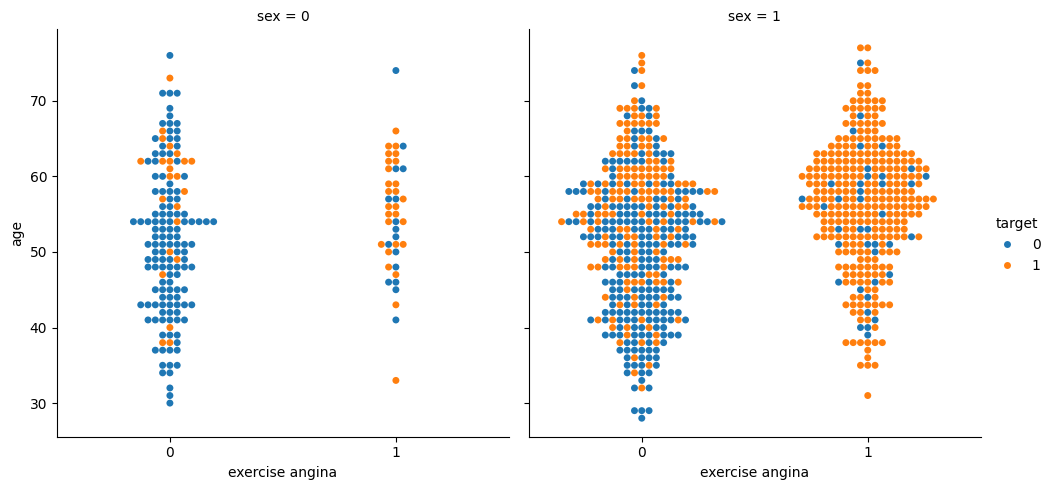

In [37]:
sns.catplot(x = "exercise angina", y = "age", hue = "target", col = "sex", kind = "swarm", data = df)
plt.show();

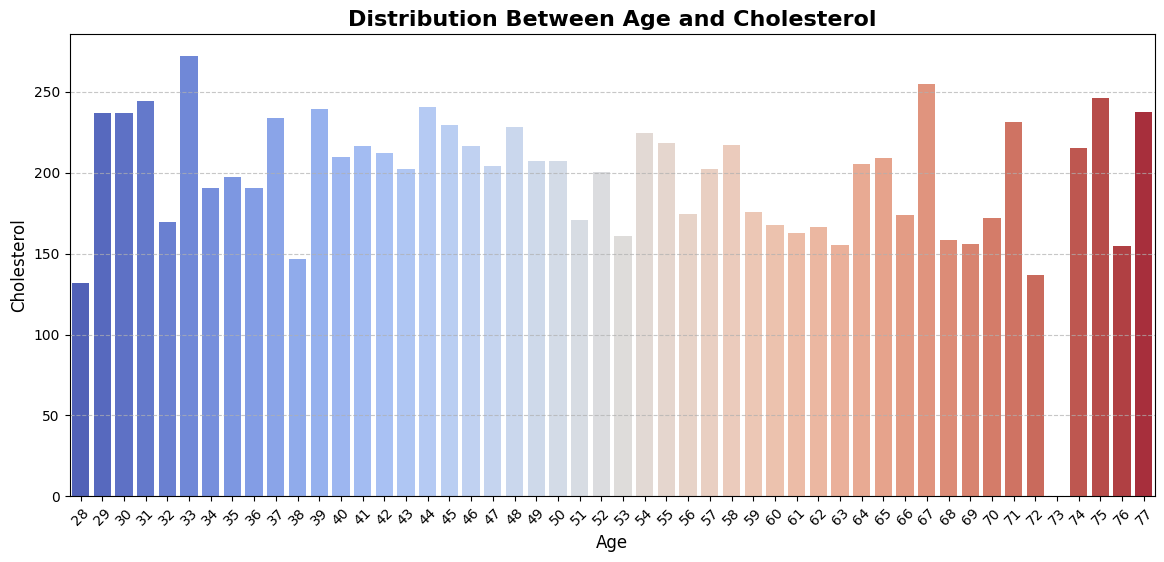

In [40]:
#distribution between age and cholestoral
plt.figure(figsize=(14,6))
sns.barplot(x="age", y="cholesterol", data=df, palette="coolwarm", ci=None)
plt.title("Distribution Between Age and Cholesterol", fontsize=16, weight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Cholesterol", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


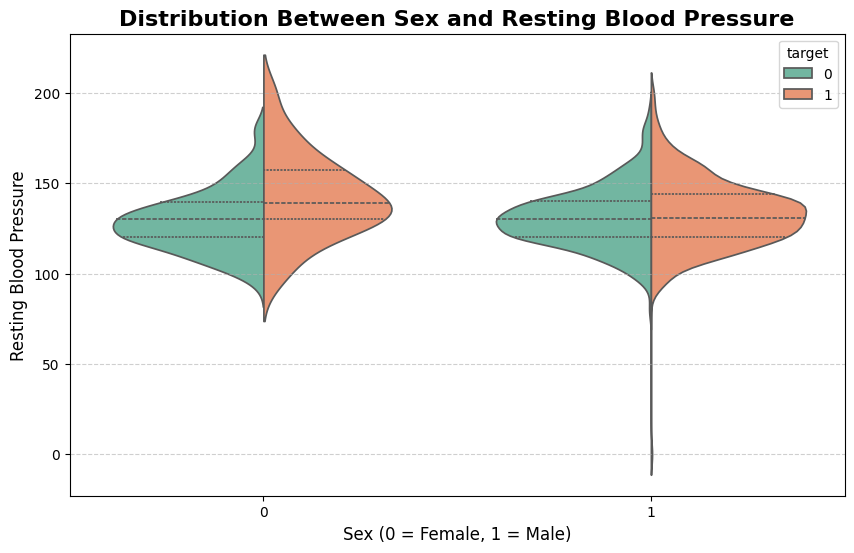

In [42]:
#distribution between sex and resting blood pressure
plt.figure(figsize=(10,6))
sns.violinplot(
    x="sex", 
    y="resting bp s", 
    hue="target", 
    data=df, 
    palette="Set2",   
    split=True,       
    inner="quartile"  
)
plt.title("Distribution Between Sex and Resting Blood Pressure", fontsize=16, weight="bold")
plt.xlabel("Sex (0 = Female, 1 = Male)", fontsize=12)
plt.ylabel("Resting Blood Pressure", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### Checking Correlations

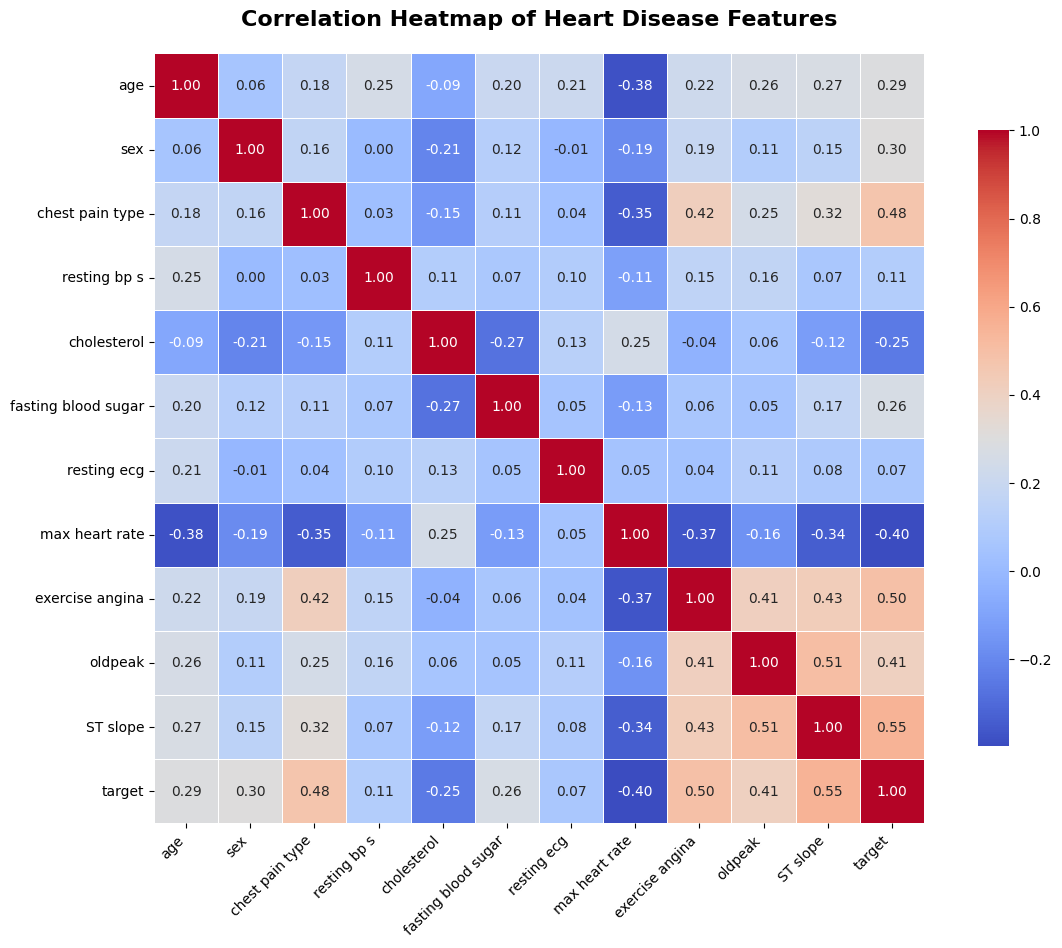

In [43]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(), 
    annot=True, 
    fmt=".2f", 
    linewidths=.7, 
    cmap="coolwarm",      
    cbar_kws={'shrink': 0.8},  
    square=True           
)
plt.title("Correlation Heatmap of Heart Disease Features", fontsize=16, weight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Modelling

In [44]:
model_df = df.copy()

In [45]:
model_df = pd.get_dummies(model_df, columns= categorical_list[:-1], drop_first= True, dtype= float)

In [46]:
model_df.head()

,age,resting bp s,cholesterol,max heart rate,oldpeak,target,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting ecg_1,resting ecg_2,exercise angina_1,ST slope_1,ST slope_2,ST slope_3
0,40,140,289,172,0.0,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,49,160,180,156,1.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,37,130,283,98,0.0,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,48,138,214,108,1.5,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,150,195,122,0.0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [47]:
x = model_df.drop(['target'], axis= 1)
y = model_df[['target']]

### Train-Test Split

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.4, random_state= 42)
print("x_train: {}".format(x_train.shape))
print("x_test: {}".format(x_test.shape))
print("y_train: {}".format(y_train.shape))
print("y_test: {}".format(y_test.shape))

x_train: (540, 16)
x_test: (361, 16)
y_train: (540, 1)
y_test: (361, 1)


### Data Augmentation

In [56]:
SEED = 42
np.random.seed(SEED)

In [57]:
def augment_age(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df[(df["age"] >= 30) & (df["age"] <= 60)].sample(n=n_samples, replace=True, random_state=seed).copy()
    df_sample["age"] += np.random.choice([-1, 1], size=n_samples)
    return df_sample

In [58]:
def augment_chol(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df.sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.randint(1, 6, size=n_samples)
    df_sample["cholesterol"] += np.where(df_sample["target"] == 1, noise, -noise)
    return df_sample

In [59]:
def augment_trestbps(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df[df["resting bp s"] <= 140].sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.randint(-5, 6, size=n_samples)
    df_sample["resting bp s"] += noise
    return df_sample

In [60]:
def augment_thalach(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df.sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.randint(-5, 6, size=n_samples)
    df_sample["max heart rate"] += noise
    return df_sample

In [61]:
def augment_oldpeak(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df.sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.normal(loc=0, scale=0.1, size=n_samples)
    safe_mask = df_sample["oldpeak"] <= 1.0
    df_sample.loc[safe_mask, "oldpeak"] += noise[safe_mask]
    df_sample.loc[~safe_mask, "oldpeak"] += np.clip(noise[~safe_mask], -0.05, 0.05)
    return df_sample

In [62]:
train_df = x_train.copy()
train_df["target"] = y_train

augmented_df = pd.concat([
    augment_age(train_df, 100),
    augment_chol(train_df, 100),
    augment_trestbps(train_df, 100),
    augment_thalach(train_df, 100),
    augment_oldpeak(train_df, 100)
], ignore_index=True)

In [63]:
train_augmented = pd.concat([train_df, augmented_df], ignore_index=True)
x_train_augmented = train_augmented.drop("target", axis=1)
y_train_augmented = train_augmented[["target"]]

In [64]:
print("Size of original x_train dataset: ", x_train.shape)
print("Size of augmented x_train dataset:", x_train_augmented.shape)
print("Size of original y_train dataset: ", y_train.shape)
print("Size of augmented y_train dataset: ", y_train_augmented.shape)

Size of original x_train dataset:  (540, 16)
Size of augmented x_train dataset: (1040, 16)
Size of original y_train dataset:  (540, 1)
Size of augmented y_train dataset:  (1040, 1)


### Scaling

In [65]:
scaler = StandardScaler()
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [66]:
x_train_augmented = scaler.fit_transform(x_train_augmented)
x_test = scaler.transform(x_test)

### Logistic Regression

In [67]:
log = LogisticRegression()
log

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
log_model = log.fit(x_train_augmented, y_train_augmented)

In [69]:
y_pred_log = log_model.predict(x_test)
print("Accuracy Rate of Logistic Regression Model => {}".format(accuracy_score(y_pred_log, y_test)))
print("Precision => {}".format(precision_score(y_test, y_pred_log)))
print("Recall => {}".format(recall_score(y_test, y_pred_log)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_log)))
print(classification_report(y_pred_log, y_test))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_log))
print("Train Score: ", log_model.score(x_train, y_train))
print("Test Score: ", log_model.score(x_test, y_test))

Accuracy Rate of Logistic Regression Model => 0.8614958448753463
Precision => 0.8756218905472637
Recall => 0.8756218905472637
F1-Score => 0.8756218905472637
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       160
           1       0.88      0.88      0.88       201

    accuracy                           0.86       361
   macro avg       0.86      0.86      0.86       361
weighted avg       0.86      0.86      0.86       361


Confusion Matrix => 
 [[135  25]
 [ 25 176]]
Train Score:  0.48333333333333334
Test Score:  0.8614958448753463


### Roc Curve

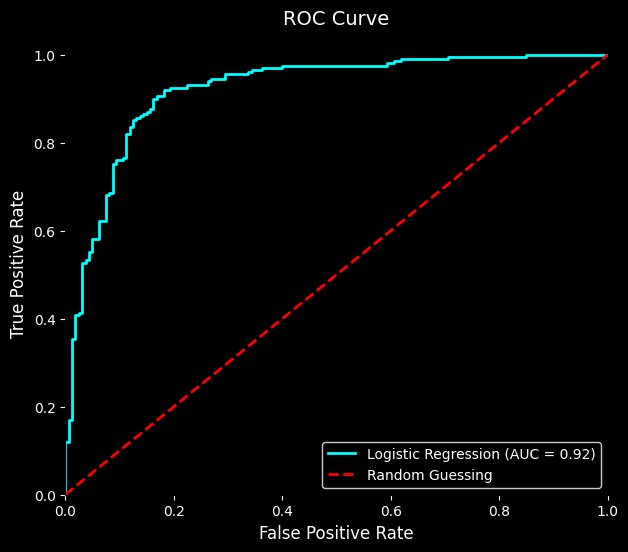

In [70]:
logit_roc_auc = roc_auc_score(y_test, log_model.predict_proba(x_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="cyan", lw=2, 
         label='Logistic Regression (AUC = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Guessing")

plt.gca().set_facecolor("black")
plt.gcf().patch.set_facecolor("black")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", color="white", fontsize=12)
plt.ylabel("True Positive Rate", color="white", fontsize=12)
plt.title("ROC Curve", color="white", fontsize=14)

plt.legend(loc="lower right", facecolor="black", edgecolor="white", labelcolor="white")
plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')

plt.show()

### KNN

In [71]:
knn = KNeighborsClassifier()
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [72]:
knn_model = knn.fit(x_train_augmented, y_train_augmented)
knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [73]:
y_pred_knn = knn_model.predict(x_test)
print("Accuracy rate of KNN Model => {}".format(accuracy_score(y_test, y_pred_knn)))
print("Precision => {}".format(precision_score(y_test, y_pred_knn)))
print("Recall => {}".format(recall_score(y_test, y_pred_knn)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_knn)))
print(classification_report(y_test, y_pred_knn))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_knn))
print("Train Score: ", knn_model.score(x_train, y_train))
print("Test Score: ", knn_model.score(x_test, y_test))

Accuracy rate of KNN Model => 0.8337950138504155
Precision => 0.8691099476439791
Recall => 0.8258706467661692
F1-Score => 0.8469387755102041
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       160
           1       0.87      0.83      0.85       201

    accuracy                           0.83       361
   macro avg       0.83      0.83      0.83       361
weighted avg       0.84      0.83      0.83       361


Confusion Matrix => 
 [[135  25]
 [ 35 166]]
Train Score:  0.6537037037037037
Test Score:  0.8337950138504155


### SVM

In [74]:
svc = SVC(random_state= 42)
svc

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [75]:
svc_model = svc.fit(x_train_augmented, y_train_augmented)
svc_model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [76]:
y_pred_svc = svc_model.predict(x_test)
print("Accuracy Rate of SVM Model => {}".format(accuracy_score(y_test, y_pred_svc)))
print("Precision => {}".format(precision_score(y_test, y_pred_svc)))
print("Recall => {}".format(recall_score(y_test, y_pred_svc)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_svc)))
print(classification_report(y_pred_svc, y_test))
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_svc))
print("Train Score: ", svc_model.score(x_train, y_train))
print("Test Score: ", svc_model.score(x_test, y_test))

Accuracy Rate of SVM Model => 0.8559556786703602
Precision => 0.8743718592964824
Recall => 0.8656716417910447
F1-Score => 0.87
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       162
           1       0.87      0.87      0.87       199

    accuracy                           0.86       361
   macro avg       0.85      0.85      0.85       361
weighted avg       0.86      0.86      0.86       361

Confusion Matrix => 
 [[135  25]
 [ 27 174]]
Train Score:  0.5425925925925926
Test Score:  0.8559556786703602


### Decision Tree

In [77]:
dt = DecisionTreeClassifier()
dt

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [78]:
dt_model = dt.fit(x_train_augmented, y_train_augmented)
dt_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [79]:
y_pred_dt = dt_model.predict(x_test)
print("Accuracy of Decision Tree Model => {}".format(accuracy_score(y_test, y_pred_dt)))
print("Precision => {}".format(precision_score(y_test, y_pred_dt)))
print("Recall => {}".format(recall_score(y_test, y_pred_dt)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_dt)))
print(classification_report(y_test, y_pred_dt))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_dt))
print("Train Score: ", dt_model.score(x_train, y_train))
print("Test Score: ", dt_model.score(x_test, y_test))

Accuracy of Decision Tree Model => 0.7479224376731302
Precision => 0.8055555555555556
Recall => 0.7213930348258707
F1-Score => 0.7611548556430446
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       160
           1       0.81      0.72      0.76       201

    accuracy                           0.75       361
   macro avg       0.75      0.75      0.75       361
weighted avg       0.75      0.75      0.75       361


Confusion Matrix => 
 [[125  35]
 [ 56 145]]
Train Score:  0.49074074074074076
Test Score:  0.7479224376731302


### Random Forest

In [80]:
rf = RandomForestClassifier(random_state= 42)
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [81]:
rf_model = rf.fit(x_train_augmented, y_train_augmented)
rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
y_pred_rf = rf_model.predict(x_test)
print("Accuracy Rate of Random Forest Model => {}".format(accuracy_score(y_test, y_pred_rf)))
print("Precision => {}".format(precision_score(y_test, y_pred_rf)))
print("Recall => {}".format(recall_score(y_test, y_pred_rf)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_rf)))
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_rf))
print("Train Score: ", rf_model.score(x_train, y_train))
print("Test Score: ", rf_model.score(x_test, y_test))

Accuracy Rate of Random Forest Model => 0.8781163434903048
Precision => 0.8866995073891626
Recall => 0.8955223880597015
F1-Score => 0.8910891089108911
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       160
           1       0.89      0.90      0.89       201

    accuracy                           0.88       361
   macro avg       0.88      0.88      0.88       361
weighted avg       0.88      0.88      0.88       361


Confusion Matrix => 
 [[137  23]
 [ 21 180]]
Train Score:  0.5425925925925926
Test Score:  0.8781163434903048


### Ridge

In [83]:
ridge = RidgeClassifier()
ridge

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",None


In [84]:
ridge_model = ridge.fit(x_train_augmented, y_train_augmented)
ridge_model

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",None


In [85]:
y_pred_ridge = ridge_model.predict(x_test)
print("Accuracy Rate of Ridge Model => {}".format(accuracy_score(y_test, y_pred_ridge)))
print("Precision => {}".format(precision_score(y_test, y_pred_ridge)))
print("Recall => {}".format(recall_score(y_test, y_pred_ridge)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_ridge)))
print(classification_report(y_test, y_pred_ridge))
print()
print("Confussion Matrix => \n", confusion_matrix(y_test, y_pred_ridge))
print("Train Score: ", ridge_model.score(x_train, y_train))
print("Test Score: ", ridge_model.score(x_test, y_test))

Accuracy Rate of Ridge Model => 0.8725761772853186
Precision => 0.8934010152284264
Recall => 0.8756218905472637
F1-Score => 0.8844221105527639
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       160
           1       0.89      0.88      0.88       201

    accuracy                           0.87       361
   macro avg       0.87      0.87      0.87       361
weighted avg       0.87      0.87      0.87       361


Confussion Matrix => 
 [[139  21]
 [ 25 176]]
Train Score:  0.45740740740740743
Test Score:  0.8725761772853186


### Light GbM

In [86]:
lgbm = LGBMClassifier()
lgbm

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [87]:
lgbm_model = lgbm.fit(x_train_augmented, y_train_augmented)
lgbm_model

[LightGBM] [Info] Number of positive: 563, number of negative: 477
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001225 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 1040, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.541346 -> initscore=0.165763
[LightGBM] [Info] Start training from score 0.165763


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [88]:
y_pred_lgbm = lgbm_model.predict(x_test)
print("Accuracy Rate of Light GBM Model => {}".format(accuracy_score(y_test, y_pred_lgbm)))
print("Precision => {}".format(precision_score(y_test, y_pred_lgbm)))
print("Recall => {}".format(recall_score(y_test, y_pred_lgbm)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_lgbm)))
print(classification_report(y_test, y_pred_lgbm))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_lgbm))
print("Train Score: ", lgbm_model.score(x_train, y_train))
print("Test Score: ", lgbm_model.score(x_test, y_test))

Accuracy Rate of Light GBM Model => 0.8587257617728532
Precision => 0.8712871287128713
Recall => 0.8756218905472637
F1-Score => 0.8734491315136477
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       160
           1       0.87      0.88      0.87       201

    accuracy                           0.86       361
   macro avg       0.86      0.86      0.86       361
weighted avg       0.86      0.86      0.86       361


Confusion Matrix => 
 [[134  26]
 [ 25 176]]
Train Score:  0.8407407407407408
Test Score:  0.8587257617728532


### XGBoost

In [89]:
xgb = XGBClassifier()
xgb

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [90]:
xgb_model = xgb.fit(x_train_augmented, y_train_augmented)
xgb_model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [91]:
y_pred_xgb = xgb_model.predict(x_test)
print("Accuracy Score of XGBoost Model => {}".format(accuracy_score(y_test, y_pred_xgb)))
print("Precision => {}".format(precision_score(y_test, y_pred_xgb)))
print("Recall => {}".format(recall_score(y_test, y_pred_xgb)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_xgb)))
print(classification_report(y_test, y_pred_xgb))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_xgb))
print("Train Score: ", xgb_model.score(x_train, y_train))
print("Test Score: ", xgb_model.score(x_test, y_test))

Accuracy Score of XGBoost Model => 0.8698060941828255
Precision => 0.8774509803921569
Recall => 0.8905472636815921
F1-Score => 0.8839506172839506
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       160
           1       0.88      0.89      0.88       201

    accuracy                           0.87       361
   macro avg       0.87      0.87      0.87       361
weighted avg       0.87      0.87      0.87       361


Confusion Matrix => 
 [[135  25]
 [ 22 179]]
Train Score:  0.5481481481481482
Test Score:  0.8698060941828255


## Model Tuning

### Logistic Regression

In [92]:
log_params = {
    "penalty": ['l1', 'l2'],
    "C": [0.0001, 0.01, 0.1, 1, 10, 100]
}

In [93]:
log_model_cv = GridSearchCV(log, log_params, cv= 10)
log_model_cv.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.0001, 0.01, ...], 'penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

In [94]:
print("Best parameters: " + str(log_model_cv.best_params_))

Best parameters: {'C': 1, 'penalty': 'l2'}


In [95]:
log_tuned = LogisticRegression(C= 1, penalty= 'l2')
log_model_tuned = log_tuned.fit(x_train_augmented, y_train_augmented)
log_model_tuned

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [96]:
y_pred_log_tuned = log_model_tuned.predict(x_test)
print("Accuracy Rate of Tuned Model => {}".format(accuracy_score(y_test, y_pred_log_tuned)))
print("Previous Accuracy => {}".format(accuracy_score(y_test, y_pred_log)))

Accuracy Rate of Tuned Model => 0.8614958448753463
Previous Accuracy => 0.8614958448753463


### KNN

In [97]:
nlist = []
for i in range(1, 11):
    nlist.append(i)

knn_params = {
    "n_neighbors": nlist,
    "weights": ['uniform', 'distance']
}

In [98]:
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid= knn_params, cv= 10)
knn_cv.fit(x_train_augmented, y_train_augmented)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [99]:
print(knn_cv.best_params_)

{'n_neighbors': 10, 'weights': 'distance'}


In [100]:
knn_tuned = KNeighborsClassifier(n_neighbors= 1, weights= "uniform")
knn_model_tuned = knn_tuned.fit(x_train_augmented, y_train_augmented)
knn_model_tuned

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [101]:
y_pred_knn_tuned = knn_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_knn_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_knn_tuned)))

Accuracy rate of tuned model => 0.8033240997229917
Previous accuracy => 0.8033240997229917


### SVM

In [84]:
svm_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

In [85]:
svm = SVC()
svm_cv = GridSearchCV(svm, param_grid= svm_params, cv = 10, n_jobs= -1, verbose= 2)
svm_cv.fit(x_train_augmented, y_train_augmented)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=2)

In [86]:
print(svm_cv.best_params_)

{'C': 10, 'kernel': 'rbf'}


In [87]:
svm_tuned = SVC(C= 10, kernel= 'rbf')
svc_model_tuned = svm_tuned.fit(x_train_augmented, y_train_augmented)
svc_model_tuned

SVC(C=10)

In [88]:
y_pred_svc_tuned = svc_model_tuned.predict(x_test)
print("Accuracy of tuned model => {}".format(accuracy_score(y_test, y_pred_svc_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_svc)))

Accuracy of tuned model => 0.8275862068965517
Previous accuracy => 0.8275862068965517


### Decision Tree

In [89]:
dt_params = {"max_depth": np.arange(2, 11),
             "max_features": np.arange(2, 15),
             "min_samples_split": [2, 5, 10, 20]}

In [90]:
dt = DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, param_grid= dt_params, cv = 10, n_jobs= -1, verbose= 2)
dt_cv.fit(x_train_augmented, y_train_augmented)

Fitting 10 folds for each of 468 candidates, totalling 4680 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'min_samples_split': [2, 5, 10, 20]},
             verbose=2)

In [91]:
print(dt_cv.best_params_)

{'max_depth': 10, 'max_features': 11, 'min_samples_split': 2}


In [92]:
dt_tuned = DecisionTreeClassifier(max_depth= 10, max_features= 10, min_samples_split= 5)
dt_model_tuned = dt_tuned.fit(x_train_augmented, y_train_augmented)
dt_model_tuned

DecisionTreeClassifier(max_depth=10, max_features=10, min_samples_split=5)

In [ ]:
y_pred_dt_tuned = dt_model_tuned.predict(x_test)
print("Accuracy of tuned model => {}".format(accuracy_score(y_test, y_pred_dt_tuned)))
print("Previous Accuracy => {}".format(accuracy_score(y_test, y_pred_dt)))

Accuracy of tuned model => 0.8620689655172413
Precious Accuracy => 0.7931034482758621


### Random Forest

In [94]:
rf_params = {
    "max_depth": np.arange(2, 11),
    "max_features": np.arange(2, 15),
    "n_estimators": [10, 50, 100, 250, 500, 1000],
    "min_samples_split": [2, 5, 10, 20]
}
rf = RandomForestClassifier()
rf_cv = GridSearchCV(rf, param_grid= rf_params, cv = 10, n_jobs= -1, verbose= 2)
rf_cv.fit(x_train, y_train)

Fitting 10 folds for each of 2808 candidates, totalling 28080 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'min_samples_split': [2, 5, 10, 20],
                         'n_estimators': [10, 50, 100, 250, 500, 1000]},
             verbose=2)

In [95]:
print(rf_cv.best_params_)

{'max_depth': 9, 'max_features': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [96]:
rf_tuned = RandomForestClassifier(max_depth= 5, max_features= 2, min_samples_split= 20, n_estimators= 50)
rf_model_tuned = rf_tuned.fit(x_train, y_train)
rf_model_tuned

RandomForestClassifier(max_depth=5, max_features=2, min_samples_split=20,
                       n_estimators=50)

In [ ]:
y_pred_rf_tuned = rf_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_rf_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_rf)))

Accuracy rate of tuned model => 0.8620689655172413
Precious accuracy => 0.8275862068965517


### LightGBM

In [98]:
lgbm_params = {
    "n_estimators": [50, 100, 200, 500],
    "learning_rate": [0.01, 0.1, 0.02, 0.05],
    "max_depth": np.arange(1, 10),
    "num_leaves": np.arange(0, 101, 10),
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1]
}
lgbm = LGBMClassifier()
lgbm_cv = GridSearchCV(lgbm, param_grid= lgbm_params, cv= 10, n_jobs= -1, verbose= 2)
lgbm_cv.fit(x_train, y_train)

Fitting 10 folds for each of 9504 candidates, totalling 95040 fits
[LightGBM] [Info] Number of positive: 140, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555556 -> initscore=0.223144
[LightGBM] [Info] Start training from score 0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

GridSearchCV(cv=10, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.02, 0.05],
                         'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'n_estimators': [50, 100, 200, 500],
                         'num_leaves': array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100]),
                         'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1]},
             verbose=2)

In [99]:
print(lgbm_cv.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 10, 'subsample': 0.5}


In [100]:
lgbm_tuned = LGBMClassifier(learning_rate= 0.1, max_depth= 1, n_estimators= 200, num_leaves= 10, subsample= 0.5)
lgbm_model_tuned = lgbm_tuned.fit(x_train, y_train)
lgbm_model_tuned

[LightGBM] [Info] Number of positive: 140, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555556 -> initscore=0.223144
[LightGBM] [Info] Start training from score 0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

LGBMClassifier(max_depth=1, n_estimators=200, num_leaves=10, subsample=0.5)

In [101]:
y_pred_lgbm_tuned = lgbm_model_tuned.predict(x_test)
print("Accuracy rate of tuned model {}".format(accuracy_score(y_test, y_pred_lgbm_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_lgbm)))

Accuracy rate of tuned model 0.8275862068965517
Previous accuracy => 0.896551724137931


### XGboost

In [102]:
xgb_params = {
    "n_estimators": [100, 500, 1000, 5000],
    "subsample": [0.6, 0.8, 1.0],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.1, 0.01, 0.2, 0.02, 0.05],
    "min_sample_split": [2, 5, 10]
}
xgb = XGBClassifier()
xgb_cv = GridSearchCV(xgb, param_grid= xgb_params, cv= 10, n_jobs= -1, verbose = 2)
xgb_cv.fit(x_train, y_train)

Fitting 10 folds for each of 720 candidates, totalling 7200 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.2, 0.02, 0.05],
                         'max_depth': [3, 4, 5, 6],
                         'min_sample_split': [2, 5, 10],
                         'n_estimators': [100, 500, 1000, 5000],
                         'subsample': [0.6, 0.8, 1.0]},
             verbose=2)

In [103]:
print(xgb_cv.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'min_sample_split': 2, 'n_estimators': 1000, 'subsample': 0.8}


In [104]:
xgb_tuned = XGBClassifier(learning_rate = 0.01, max_depth = 3, min_sample_split = 2, n_estimators = 1000, subsample = 0.8)
xgb_model_tuned = xgb_tuned.fit(x_train, y_train)
xgb_model_tuned

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, min_sample_split=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [105]:
y_pred_xgb_tuned = xgb_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_xgb_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_xgb)))

Accuracy rate of tuned model => 0.7931034482758621
Previous accuracy => 0.8620689655172413


### Model Comparison

In [102]:
log_score = accuracy_score(y_test, y_pred_log) * 100
knn_score = accuracy_score(y_test, y_pred_knn) * 100
svm_score = accuracy_score(y_test, y_pred_svc) * 100
dt_score = accuracy_score(y_test, y_pred_dt) * 100
rf_score = accuracy_score(y_test, y_pred_rf) * 100
ridge_score = accuracy_score(y_test, y_pred_ridge) * 100
lgbm_score = accuracy_score(y_test, y_pred_lgbm) * 100
xgb_score = accuracy_score(y_test, y_pred_xgb) * 100

In [103]:
print(log_score)

86.14958448753463


In [104]:
results = {
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", 
              "Random Forest", "Ridge", "LightGBM", "XGBoost"],
    "Accuracy (%)": [log_score, knn_score, svm_score, dt_score,
                     rf_score, ridge_score, lgbm_score, xgb_score]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy (%)
0,Logistic Regression,86.149584
1,KNN,83.379501
2,SVM,85.595568
3,Decision Tree,74.792244
4,Random Forest,87.811634
5,Ridge,87.257618
6,LightGBM,85.872576
7,XGBoost,86.980609


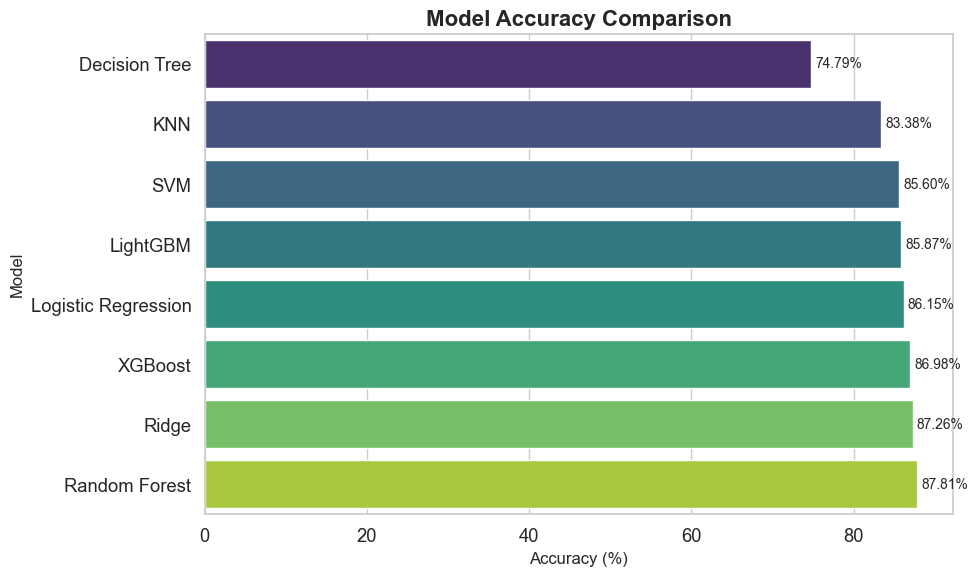

In [105]:
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,6))
barplot = sns.barplot(
    x="Accuracy (%)", 
    y="Model", 
    data=results_df.sort_values("Accuracy (%)", ascending=True),
    palette="viridis"
)
plt.title("Model Accuracy Comparison", fontsize=16, weight="bold")
plt.xlabel("Accuracy (%)", fontsize=12)
plt.ylabel("Model", fontsize=12)

for p in barplot.patches:
    plt.text(
        p.get_width() + 0.5,      
        p.get_y() + p.get_height()/2,  
        f"{p.get_width():.2f}%", 
        va="center", fontsize=10
    )

plt.tight_layout()
plt.show()

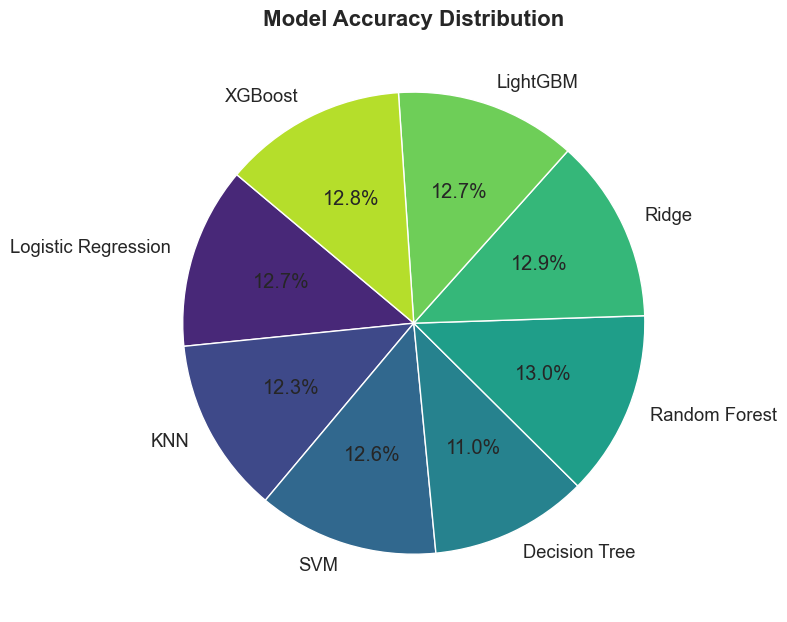

In [106]:
plt.figure(figsize=(8,8))
colors = sns.color_palette("viridis", len(results_df))

plt.pie(
    results_df["Accuracy (%)"],
    labels=results_df["Model"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor":"white","linewidth":1}
)

plt.title("Model Accuracy Distribution", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

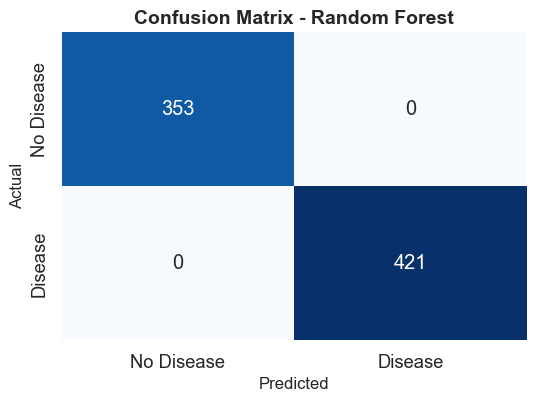

In [70]:
cm_log = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix - Random Forest", fontsize=14, weight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.show()

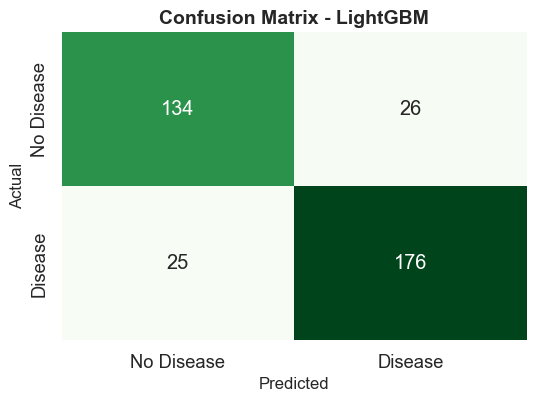

In [107]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix - LightGBM", fontsize=14, weight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.show()